# GCS, RespRate, BUN, Creatinine and Urine vs In-Hospital Mortality

This notebook covers my part of the group EDA. For each of the five variables I am
responsible for - GCS, respiratory rate, BUN, creatinine and urine output - I look at:

- how the variable is distributed and whether the values look reasonable,
- how it differs between patients who survived and patients who died,
- whether the pattern changes across age groups and between males and females.

The coding conventions already used in the group's work are kept here:
`In.hospital_death` is 0 = survived and 1 = died, Gender is 0 = Male and 1 = Female,
and age groups follow the project convention (Under 40, 40-60, 60-75, Over 75).
Only the `.x` columns are used, as agreed by the group.

Everything below is an observation from this dataset, not a causal claim.


## Setup

Loading the preprocessed ICU data and preparing the grouping columns used later.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Preprocessed ICU data.csv')
print(df.shape)


(1474, 232)


In [2]:
# Grouping columns used throughout the notebook
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 40, 60, 75, 100],
    labels=['Under 40', '40-60', '60-75', 'Over 75']
)
df['Death'] = df['In.hospital_death'].map({0: 'Survived', 1: 'Died'})
df['Sex'] = df['Gender'].map({0: 'Male', 1: 'Female'})

print(df['AgeGroup'].value_counts(dropna=False).sort_index())
print()
print(df['Death'].value_counts())
print()
print(df['Sex'].value_counts(dropna=False))


AgeGroup
Under 40     55
40-60       281
60-75       454
Over 75     684
Name: count, dtype: int64

Death
Survived    920
Died        554
Name: count, dtype: int64

Sex
Female    796
Male      676
NaN         2
Name: count, dtype: int64


In [3]:
# Two small helpers so the plots below stay in the same style
def outcome_boxplot(y, ylabel, showfliers=True):
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='In.hospital_death', y=y, hue='In.hospital_death',
                palette='coolwarm', legend=False, showfliers=showfliers)
    plt.title(f'{ylabel} Distribution by Survival Outcome')
    plt.xlabel('In-Hospital Death (0 = Survived, 1 = Died)')
    plt.ylabel(ylabel)
    plt.show()

def profile_boxplot(x, y, xlabel, ylabel, showfliers=True):
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=x, y=y, hue='Death', palette='coolwarm', showfliers=showfliers)
    plt.title(f'{ylabel} by {xlabel} and Survival Outcome')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(title='Outcome')
    plt.show()


## Patient Profile: Age and Gender

Before looking at the five variables, I check how mortality itself is distributed
across the patient profile groups, so the per-variable sections have a baseline.


          count  mean
AgeGroup             
Under 40     55  63.6
40-60       281  37.7
60-75       454  33.9
Over 75     684  37.9


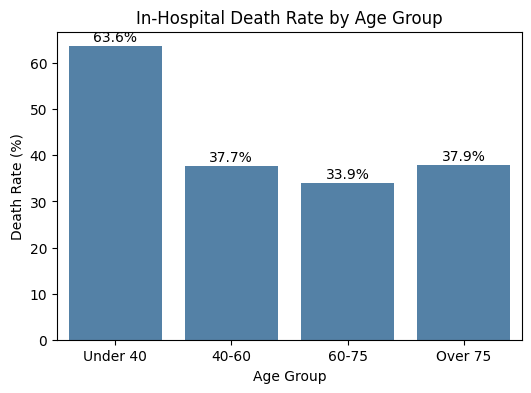

In [4]:
age_mort = df.groupby('AgeGroup', observed=True)['In.hospital_death'].agg(['count', 'mean'])
age_mort['mean'] = age_mort['mean'] * 100
print(age_mort.round(1))

plt.figure(figsize=(6, 4))
sns.barplot(x=age_mort.index.astype(str), y=age_mort['mean'], color='steelblue')
for i, v in enumerate(age_mort['mean']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.title('In-Hospital Death Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Death Rate (%)')
plt.show()


The overall death rate is fairly similar across the 40-60, 60-75 and Over 75 groups
(around 34-38%). The Under 40 group stands out with a much higher rate (63.6%), but it
only contains 55 patients, so the estimate is unstable - one or two extra deaths change
it a lot. Age alone does not show a clean "older means higher mortality" pattern here.


        count  mean
Sex                
Female    796  37.7
Male      676  37.4


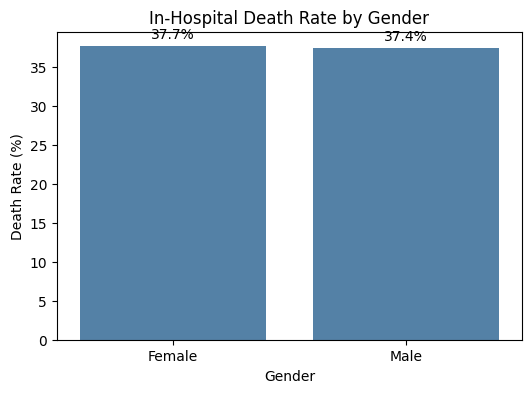

In [5]:
sex_mort = df[df['Sex'].notna()].groupby('Sex')['In.hospital_death'].agg(['count', 'mean'])
sex_mort['mean'] = sex_mort['mean'] * 100
print(sex_mort.round(1))

plt.figure(figsize=(6, 4))
sns.barplot(x=sex_mort.index, y=sex_mort['mean'], color='steelblue')
for i, v in enumerate(sex_mort['mean']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.title('In-Hospital Death Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Death Rate (%)')
plt.show()


Mortality is almost identical for males (37.4%) and females (37.7%), so gender on its
own does not separate outcomes in this dataset. Note that 2 records carry an invalid
Gender value (neither 0 nor 1); they are excluded from the gender plots only and are
not removed from the data.


## GCS

The Glasgow Coma Scale (GCS) scores a patient's level of consciousness from 3 (deep
unresponsiveness) to 15 (fully alert). Lower values mean a less conscious patient.
The dataset contains the minimum, maximum and mean GCS recorded for each patient (.x columns).


### Data Check


In [6]:
gcs_cols = ['Min_GCS.x', 'Max_GCS.x', 'Mean_GCS.x']

print(df[gcs_cols].dtypes)
print()
print('Missing values:')
print(df[gcs_cols].isna().sum())
print()
df[gcs_cols].describe().round(2)


Min_GCS.x     float64
Max_GCS.x     float64
Mean_GCS.x    float64
dtype: object

Missing values:
Min_GCS.x     0
Max_GCS.x     0
Mean_GCS.x    0
dtype: int64



,Min_GCS.x,Max_GCS.x,Mean_GCS.x
count,1474.00,1474.00,1474.00
mean,9.02,12.34,10.83
std,4.67,3.35,3.75
min,3.00,3.00,3.00
25%,3.25,10.00,8.00
50%,8.00,15.00,11.00
75%,14.00,15.00,14.80
max,15.00,15.00,15.00


In [7]:
print('Values outside the possible GCS range 3-15:')
print(((df[gcs_cols] < 3) | (df[gcs_cols] > 15)).sum())


Values outside the possible GCS range 3-15:
Min_GCS.x     0
Max_GCS.x     0
Mean_GCS.x    0
dtype: int64


All three GCS columns are complete (no missing values) and every value sits inside the
possible 3-15 range, so there is nothing to clean here. Min_GCS.x is heavily bunched at
the bottom (first quartile 3.25), meaning many patients dropped to the lowest score at
some point during their stay.


### GCS and Mortality


In [8]:
summary = df.groupby('In.hospital_death')[gcs_cols].agg(['count', 'mean', 'median'])
summary.T.round(2)


In.hospital_death       0       1
Min_GCS.x  count   920.00  554.00
           mean      9.61    8.04
           median   10.00    7.00
Max_GCS.x  count   920.00  554.00
           mean     13.00   11.24
           median   15.00   11.00
Mean_GCS.x count   920.00  554.00
           mean     11.54    9.66
           median   12.20    9.18

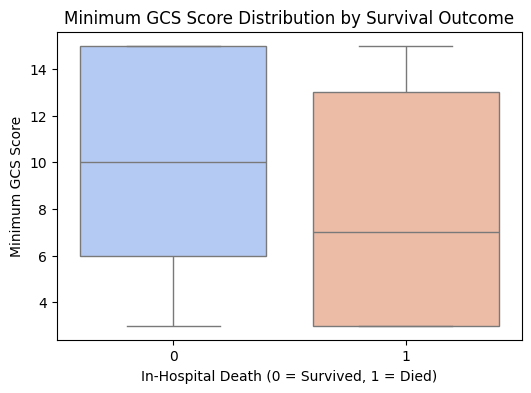

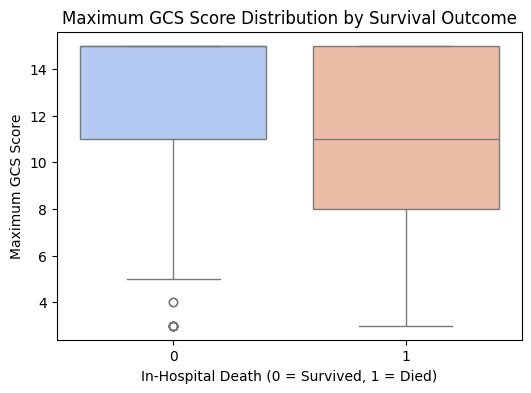

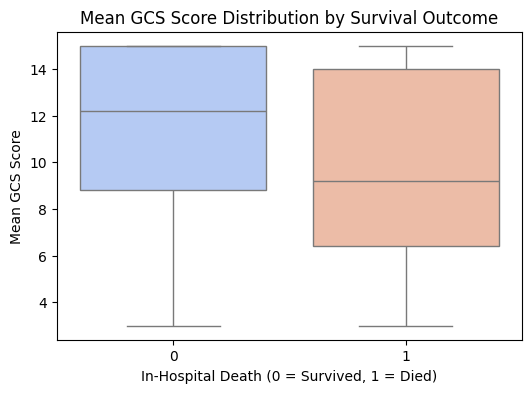

In [9]:
outcome_boxplot('Min_GCS.x', 'Minimum GCS Score')
outcome_boxplot('Max_GCS.x', 'Maximum GCS Score')
outcome_boxplot('Mean_GCS.x', 'Mean GCS Score')


Patients who died clearly sit lower on all three GCS measures: their mean Min/Max/Mean
GCS is 8.04 / 11.24 / 9.66 against 9.61 / 13.00 / 11.54 for survivors, and the medians
show the same shift. The boxplots show the whole died distribution moved downwards
rather than a change caused by a few extreme patients. Of the five variables in this
notebook, GCS shows the clearest separation between the two outcomes.


### GCS and Age


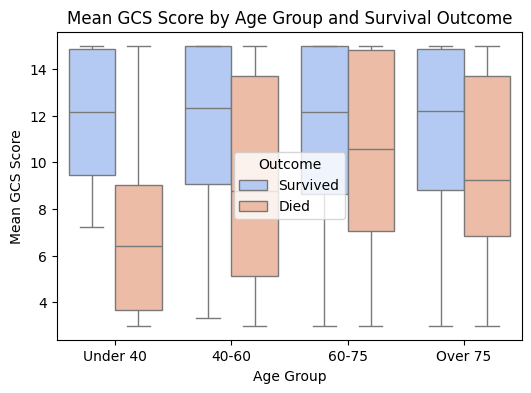

In.hospital_death      0      1
AgeGroup                       
Under 40           11.87   7.10
40-60              11.62   9.04
60-75              11.47  10.56
Over 75            11.53   9.73


In [10]:
profile_boxplot('AgeGroup', 'Mean_GCS.x', 'Age Group', 'Mean GCS Score')

print(df.pivot_table(index='AgeGroup', columns='In.hospital_death',
                     values='Mean_GCS.x', aggfunc='mean', observed=True).round(2))


Survivors sit at a very similar mean GCS (about 11.5-11.9) in every age group. Among
patients who died the GCS is lower everywhere, and the gap is widest in the Under 40
group (11.87 vs 7.10) - although that group is small (55 patients) - and narrowest in
the 60-75 group (11.47 vs 10.56). The direction of the GCS-mortality association is the
same across all ages; age does not flip or remove it.


### GCS and Gender


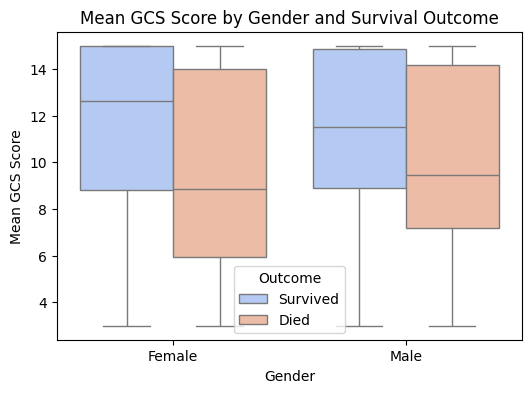

In.hospital_death      0      1
Sex                            
Female             11.61   9.37
Male               11.45  10.03


In [11]:
profile_boxplot('Sex', 'Mean_GCS.x', 'Gender', 'Mean GCS Score')

d = df[df['Sex'].notna()]
print(d.pivot_table(index='Sex', columns='In.hospital_death',
                    values='Mean_GCS.x', aggfunc='mean').round(2))


Male and female survivors have almost the same mean GCS (11.45 vs 11.61). Among
patients who died, females average 9.37 against 10.03 for males, so the drop in GCS
between survivors and non-survivors is slightly deeper for females, but the difference
between the genders is small compared with the survivor/died gap itself.


### GCS Summary

- Lower GCS is strongly associated with in-hospital death in this dataset, on the min,
  max and mean measures alike.
- The association holds in every age group and in both genders; neither age nor gender
  changes its direction.
- The Under 40 group shows the largest survivor/died gap but has only 55 patients, so
  that part of the pattern should be read with care.


## RespRate

Respiratory rate is the number of breaths per minute. The dataset again provides the
minimum, maximum and mean value per patient (.x columns).


### Data Check


In [12]:
rr_cols = ['Min_RespRate.x', 'Max_RespRate.x', 'Mean_RespRate.x']

print(df[rr_cols].dtypes)
print()
print('Missing values:')
print(df[rr_cols].isna().sum())
print()
df[rr_cols].describe().round(2)


Min_RespRate.x     float64
Max_RespRate.x     float64
Mean_RespRate.x    float64
dtype: object

Missing values:
Min_RespRate.x     0
Max_RespRate.x     0
Mean_RespRate.x    0
dtype: int64



,Min_RespRate.x,Max_RespRate.x,Mean_RespRate.x
count,1474.00,1474.00,1474.00
mean,13.35,27.77,19.86
std,2.24,3.44,2.27
min,0.00,16.00,10.78
25%,13.20,27.56,19.67
50%,13.20,27.56,19.67
75%,13.20,27.56,19.67
max,25.00,57.00,39.41


In [13]:
top = df['Mean_RespRate.x'].value_counts(normalize=True).head(1)
print('Most common Mean_RespRate.x value and its share of rows:')
print((top * 100).round(1))
print()
same_rows = (df[rr_cols[0]] == 13.1980018165304)
print('Rows sharing the identical constant triplet:', same_rows.sum(),
      f'({same_rows.mean() * 100:.1f}% of the data)')
print(f"Death rate among these rows: {df.loc[same_rows, 'In.hospital_death'].mean() * 100:.1f}%")
print(f"Death rate among the rest:    {df.loc[~same_rows, 'In.hospital_death'].mean() * 100:.1f}%")
print()
print('Min_RespRate.x equal to 0 (not physically possible):', (df['Min_RespRate.x'] == 0).sum())


Most common Mean_RespRate.x value and its share of rows:
Mean_RespRate.x
19.666415    74.0
Name: proportion, dtype: float64

Rows sharing the identical constant triplet: 1091 (74.0% of the data)
Death rate among these rows: 42.8%
Death rate among the rest:    22.7%

Min_RespRate.x equal to 0 (not physically possible): 9


There are no missing values, but there is a data quality issue worth stating plainly:
1091 of the 1474 records (74.0%) carry exactly the same triplet of RespRate values
(13.20 / 27.56 / 19.67), which looks like values that were filled in during
preprocessing rather than measured for each patient. These rows also have a different
death rate (42.8%) from the remaining rows (22.7%), so the filling was not random.
This limits how much any RespRate result can be trusted. There are also a handful of
impossible Min_RespRate.x values of 0, which I keep in the data but flag here.


### RespRate and Mortality


In [14]:
summary = df.groupby('In.hospital_death')[rr_cols].agg(['count', 'mean', 'median'])
summary.T.round(2)


In.hospital_death            0       1
Min_RespRate.x  count   920.00  554.00
                mean     13.33   13.39
                median   13.20   13.20
Max_RespRate.x  count   920.00  554.00
                mean     27.69   27.92
                median   27.56   27.56
Mean_RespRate.x count   920.00  554.00
                mean     19.79   19.97
                median   19.67   19.67

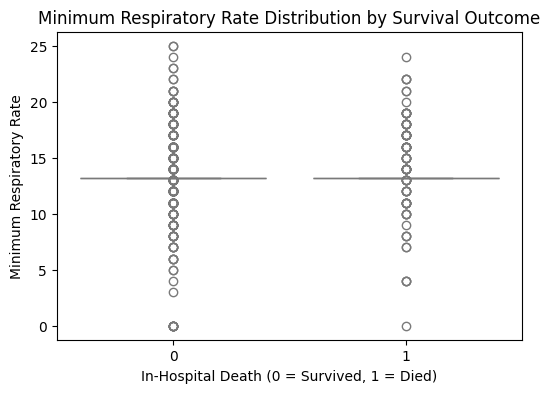

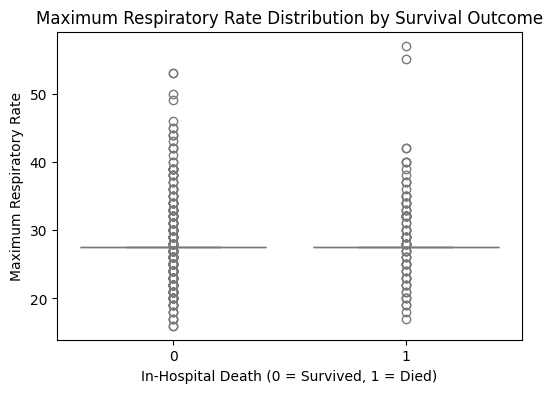

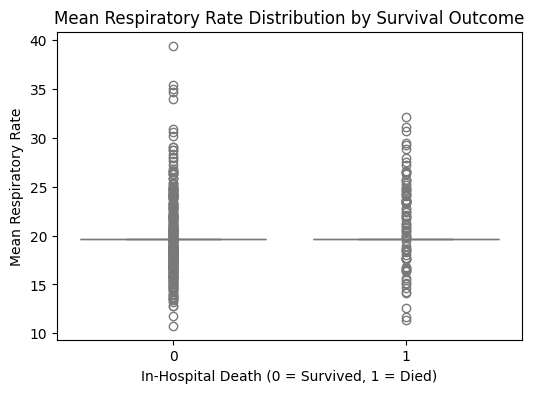

In [15]:
outcome_boxplot('Min_RespRate.x', 'Minimum Respiratory Rate')
outcome_boxplot('Max_RespRate.x', 'Maximum Respiratory Rate')
outcome_boxplot('Mean_RespRate.x', 'Mean Respiratory Rate')


Survivors and patients who died have almost identical respiratory rate summaries
(mean 19.79 vs 19.97, identical medians). The boxplots overlap almost completely.
Unlike GCS, respiratory rate does not separate the two outcome groups in this dataset.


### RespRate and Age


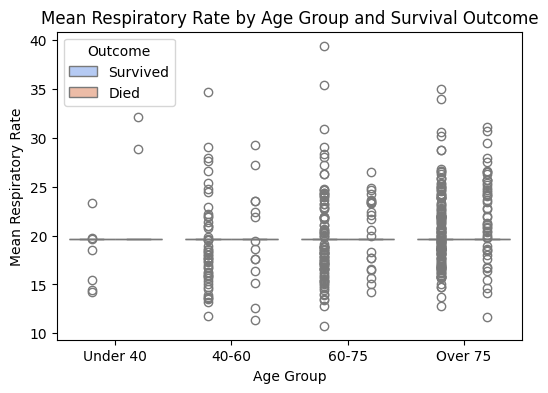

In.hospital_death      0      1
AgeGroup                       
Under 40           19.06  20.28
40-60              19.50  19.68
60-75              19.73  19.82
Over 75            19.99  20.13


In [16]:
profile_boxplot('AgeGroup', 'Mean_RespRate.x', 'Age Group', 'Mean Respiratory Rate')

print(df.pivot_table(index='AgeGroup', columns='In.hospital_death',
                     values='Mean_RespRate.x', aggfunc='mean', observed=True).round(2))


Every age-and-outcome group averages between roughly 19 and 20 breaths per minute, and
the differences (at most about 1 breath) are far smaller than the spread within each
group. No age group shows a meaningful RespRate-mortality difference.


### RespRate and Gender


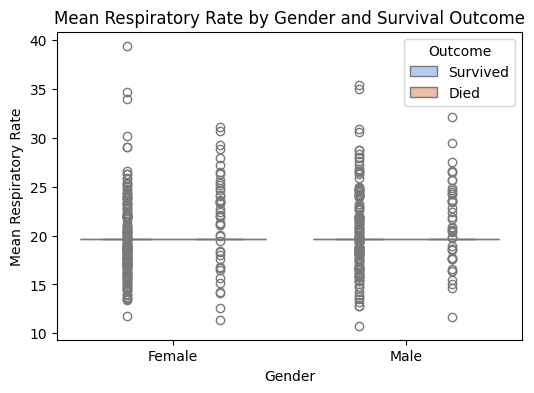

In.hospital_death      0      1
Sex                            
Female             19.73  19.98
Male               19.87  19.96


In [17]:
profile_boxplot('Sex', 'Mean_RespRate.x', 'Gender', 'Mean Respiratory Rate')

d = df[df['Sex'].notna()]
print(d.pivot_table(index='Sex', columns='In.hospital_death',
                    values='Mean_RespRate.x', aggfunc='mean').round(2))


The same picture holds for gender: males and females, survivors and non-survivors all
average within about a quarter of a breath of each other.


### RespRate Summary

- Mean, min and max respiratory rate show no visible association with in-hospital
  death in this dataset.
- The pattern is flat across age groups and genders as well.
- The main caveat is the data itself: 74% of records share one identical imputed value
  set, so real variation may have been washed out. I would not conclude that respiratory
  rate is clinically irrelevant - only that this file cannot show a signal.


## BUN

Blood urea nitrogen (BUN, mg/dL) is a kidney-related blood marker; higher values
usually indicate reduced kidney function or dehydration. The .x columns give the min,
max and mean per patient.


### Data Check


In [18]:
bun_cols = ['Min_BUN.x', 'Max_BUN.x', 'Mean_BUN.x']

print(df[bun_cols].dtypes)
print()
print('Missing values:')
print(df[bun_cols].isna().sum())
print()
df[bun_cols].describe().round(2)


Min_BUN.x     float64
Max_BUN.x     float64
Mean_BUN.x    float64
dtype: object

Missing values:
Min_BUN.x     0
Max_BUN.x     0
Mean_BUN.x    0
dtype: int64



,Min_BUN.x,Max_BUN.x,Mean_BUN.x
count,1474.00,1474.00,1474.00
mean,31.42,34.84,33.14
std,24.02,26.33,25.05
min,0.00,3.00,3.00
25%,15.00,17.00,16.00
50%,24.00,26.00,25.00
75%,40.00,44.00,42.00
max,172.00,184.00,178.00


In [19]:
print('Records with any BUN value above 100 mg/dL:')
print((df[bun_cols] > 100).sum())


Records with any BUN value above 100 mg/dL:
Min_BUN.x     33
Max_BUN.x     47
Mean_BUN.x    40
dtype: int64


No missing values. The values span 0 to 184 mg/dL with the mean (about 33) well above
the median (about 25), a typical right-skewed pattern for this marker. Extremely high
values (above 100) exist for 33-47 records per column; they look unusual but are
physically possible in critically ill patients, so I keep them - the boxplots below
show where they sit.


### BUN and Mortality


In [20]:
summary = df.groupby('In.hospital_death')[bun_cols].agg(['count', 'mean', 'median'])
summary.T.round(2)


In.hospital_death       0       1
Min_BUN.x  count   920.00  554.00
           mean     29.35   34.85
           median   22.00   26.00
Max_BUN.x  count   920.00  554.00
           mean     32.65   38.48
           median   24.00   30.00
Mean_BUN.x count   920.00  554.00
           mean     31.03   36.64
           median   23.50   28.00

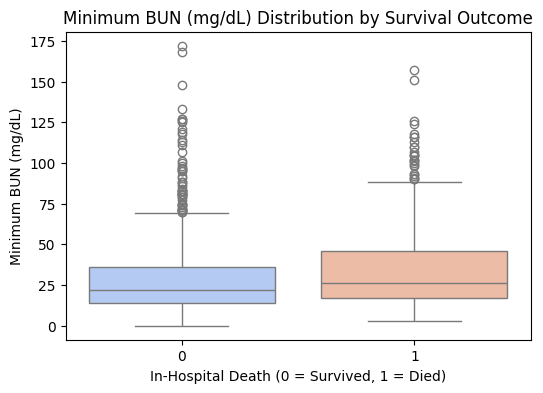

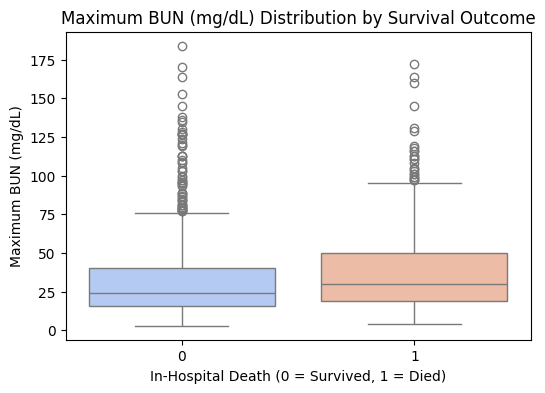

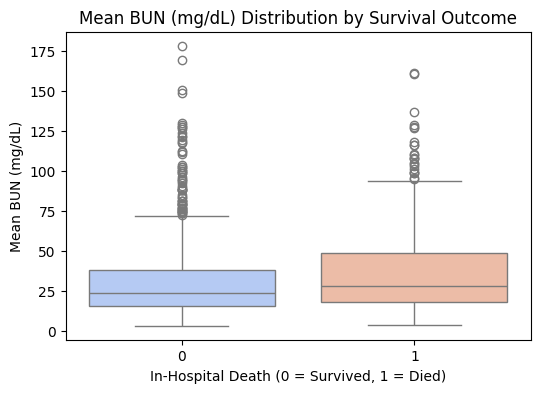

In [21]:
outcome_boxplot('Min_BUN.x', 'Minimum BUN (mg/dL)')
outcome_boxplot('Max_BUN.x', 'Maximum BUN (mg/dL)')
outcome_boxplot('Mean_BUN.x', 'Mean BUN (mg/dL)')


Patients who died have consistently higher BUN: mean 36.6 vs 31.0 and median 28 vs 23.5
on Mean_BUN.x, with the same direction on min and max. The separation is visible but
much weaker than for GCS - the boxes still overlap heavily, and the many extreme high
values stretch the axis.


### BUN and Age


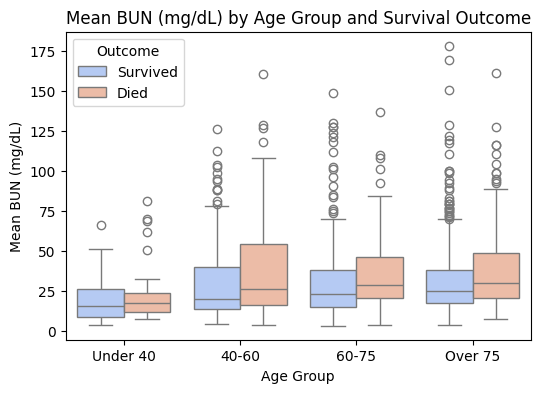

In.hospital_death      0      1
AgeGroup                       
Under 40           20.52  23.26
40-60              29.88  39.79
60-75              30.73  35.44
Over 75            32.20  37.88


In [22]:
profile_boxplot('AgeGroup', 'Mean_BUN.x', 'Age Group', 'Mean BUN (mg/dL)')

print(df.pivot_table(index='AgeGroup', columns='In.hospital_death',
                     values='Mean_BUN.x', aggfunc='mean', observed=True).round(2))


BUN rises with age in both outcome groups (survivors from about 20.5 in the Under 40
group to 32.2 over 75). Within every age group, patients who died have the higher BUN,
with the largest gap in the 40-60 group (29.9 vs 39.8). The Under 40 group shows a gap
too but contains few patients. Age does not change the direction of the association.


### BUN and Gender


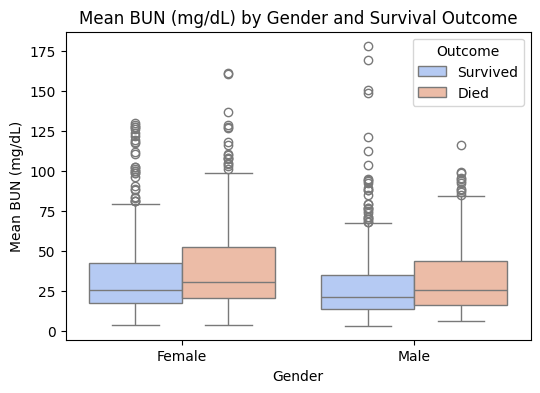

In.hospital_death      0      1
Sex                            
Female             33.26  40.04
Male               28.46  32.68


In [23]:
profile_boxplot('Sex', 'Mean_BUN.x', 'Gender', 'Mean BUN (mg/dL)')

d = df[df['Sex'].notna()]
print(d.pivot_table(index='Sex', columns='In.hospital_death',
                    values='Mean_BUN.x', aggfunc='mean').round(2))


Females have higher BUN than males in both outcome groups. The survivor/died gap is
also somewhat wider for females (33.3 vs 40.0, about 6.8 points) than for males
(28.5 vs 32.7, about 4.2 points), so the BUN-mortality association appears slightly
stronger among female patients.


### BUN Summary

- Higher BUN is associated with higher in-hospital mortality, consistently across min,
  mean and max measures.
- The association appears in every age group; middle-aged patients (40-60) show the
  widest gap.
- Both genders show it, with a somewhat wider gap among females.
- The marker is right-skewed with many extreme values, so group means are pulled
  upwards; medians tell the same story here.


## Creatinine

Serum creatinine (mg/dL) is another kidney marker, commonly used to judge renal
function. Again the min, max and mean .x columns are available.


### Data Check


In [24]:
cre_cols = ['Min_Creatinine.x', 'Max_Creatinine.x', 'Mean_Creatinine.x']

print(df[cre_cols].dtypes)
print()
print('Missing values:')
print(df[cre_cols].isna().sum())
print()
df[cre_cols].describe().round(2)


Min_Creatinine.x     float64
Max_Creatinine.x     float64
Mean_Creatinine.x    float64
dtype: object

Missing values:
Min_Creatinine.x     0
Max_Creatinine.x     0
Mean_Creatinine.x    0
dtype: int64



,Min_Creatinine.x,Max_Creatinine.x,Mean_Creatinine.x
count,1474.00,1474.00,1474.00
mean,1.56,1.76,1.66
std,1.57,1.77,1.67
min,0.20,0.20,0.20
25%,0.70,0.80,0.75
50%,1.00,1.10,1.10
75%,1.70,1.90,1.80
max,12.60,12.90,12.73


In [25]:
print('Records with any creatinine value above 5 mg/dL:')
print((df[cre_cols] > 5).sum())


Records with any creatinine value above 5 mg/dL:
Min_Creatinine.x     72
Max_Creatinine.x     85
Mean_Creatinine.x    81
dtype: int64


No missing values. Values run from 0.2 to 12.9 mg/dL; the median is 1.0-1.1 while the
mean is around 1.6-1.8, so the distribution is strongly right-skewed. Roughly 70-85 records
per column sit above 5 mg/dL. These are plausible for ICU patients with severe kidney
injury, so I keep them and rely on medians when the mean looks inflated.


### Creatinine and Mortality


In [26]:
summary = df.groupby('In.hospital_death')[cre_cols].agg(['count', 'mean', 'median'])
summary.T.round(2)


In.hospital_death              0       1
Min_Creatinine.x  count   920.00  554.00
                  mean      1.51    1.65
                  median    1.00    1.15
Max_Creatinine.x  count   920.00  554.00
                  mean      1.69    1.88
                  median    1.10    1.30
Mean_Creatinine.x count   920.00  554.00
                  mean      1.60    1.76
                  median    1.00    1.25

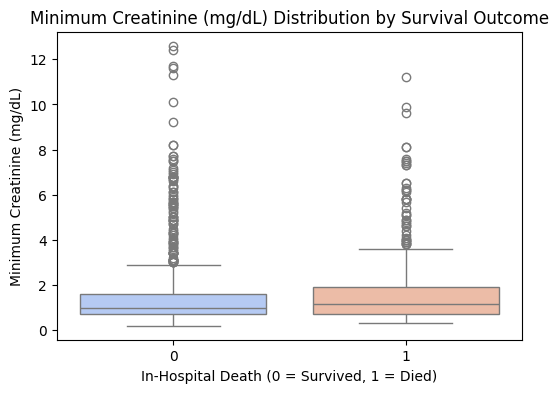

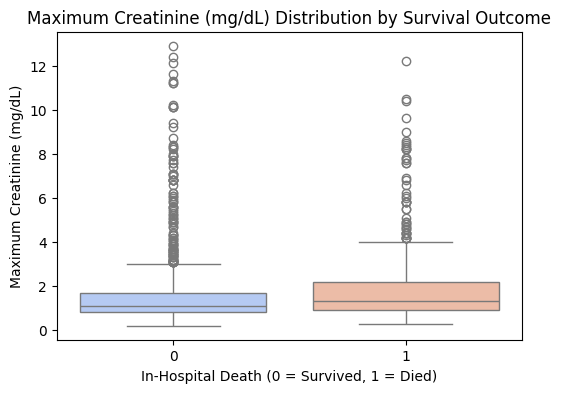

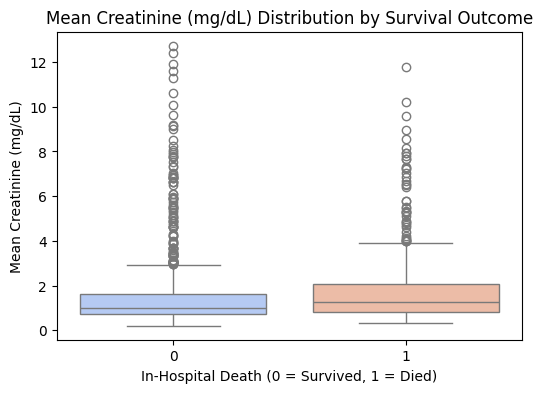

In [27]:
outcome_boxplot('Min_Creatinine.x', 'Minimum Creatinine (mg/dL)')
outcome_boxplot('Max_Creatinine.x', 'Maximum Creatinine (mg/dL)')
outcome_boxplot('Mean_Creatinine.x', 'Mean Creatinine (mg/dL)')


Patients who died have somewhat higher creatinine (mean 1.76 vs 1.60, median 1.25 vs
1.00). The difference is modest - much smaller than the spread within each group - so
creatinine alone separates the outcomes only weakly.


### Creatinine and Age


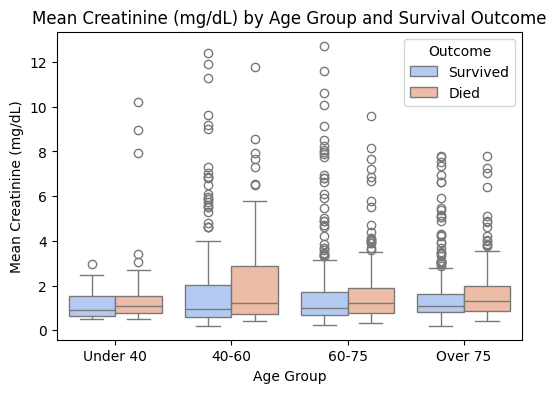

In.hospital_death     0     1
AgeGroup                     
Under 40           1.16  1.89
40-60              1.94  2.14
60-75              1.68  1.76
Over 75            1.43  1.60


In [28]:
profile_boxplot('AgeGroup', 'Mean_Creatinine.x', 'Age Group', 'Mean Creatinine (mg/dL)')

print(df.pivot_table(index='AgeGroup', columns='In.hospital_death',
                     values='Mean_Creatinine.x', aggfunc='mean', observed=True).round(2))


The survivor/died gap is not uniform across age. It is most visible in the Under 40
group (1.16 vs 1.89, though only 55 patients) and in the 40-60 group (1.94 vs 2.14,
the highest absolute levels), and it nearly disappears in the 60-75 and Over 75 groups
(gaps of about 0.1-0.2). So the little creatinine signal this dataset has is
concentrated in younger and middle-aged patients.


### Creatinine and Gender


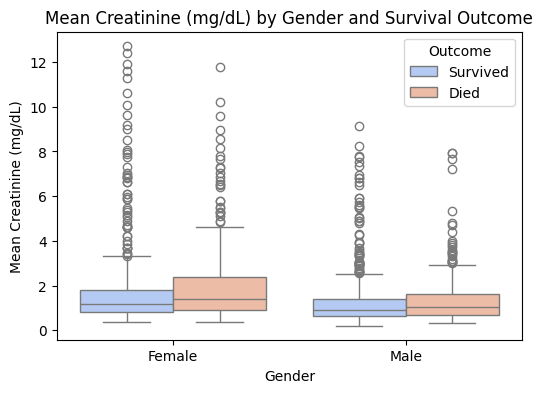

In.hospital_death     0     1
Sex                          
Female             1.78  2.05
Male               1.40  1.43


In [29]:
profile_boxplot('Sex', 'Mean_Creatinine.x', 'Gender', 'Mean Creatinine (mg/dL)')

d = df[df['Sex'].notna()]
print(d.pivot_table(index='Sex', columns='In.hospital_death',
                    values='Mean_Creatinine.x', aggfunc='mean').round(2))


This is the clearest gender contrast among the five variables. Male survivors and male
non-survivors have almost the same mean creatinine (1.40 vs 1.43), while females show
a clear gap (1.78 vs 2.05). In this dataset the creatinine-mortality association comes
almost entirely from the female patients.


### Creatinine Summary

- Creatinine shows only a weak association with in-hospital death overall.
- The association is stronger for younger/middle-aged patients and largely absent in
  the two older groups.
- It is clearly visible in females and essentially absent in males, which is the most
  interesting patient-profile finding for this variable.
- Strong right skew means medians are the safer summary.


## Urine

The urine columns record urine output (min, max and mean per patient). The unit is not
documented in the dataset file, so I focus on relative differences between groups
rather than absolute clinical values. The distribution is heavily right-skewed, so
several plots below hide the extreme points (showfliers=False) purely for readability -
the full range is always in the tables, and no data is removed.


### Data Check


In [30]:
ur_cols = ['Min_Urine.x', 'Max_Urine.x', 'Mean_Urine.x']

print(df[ur_cols].dtypes)
print()
print('Missing values:')
print(df[ur_cols].isna().sum())
print()
df[ur_cols].describe().round(2)


Min_Urine.x     float64
Max_Urine.x     float64
Mean_Urine.x    float64
dtype: object

Missing values:
Min_Urine.x     0
Max_Urine.x     0
Mean_Urine.x    0
dtype: int64



,Min_Urine.x,Max_Urine.x,Mean_Urine.x
count,1474.00,1474.00,1474.00
mean,32.71,420.63,117.45
std,60.99,510.51,122.12
min,0.00,0.00,0.00
25%,7.00,160.00,55.14
50%,20.00,300.00,92.64
75%,38.60,510.94,142.24
max,1100.00,11000.00,3030.00


In [31]:
for c in ur_cols:
    print(f'{c}: zeros = {(df[c] == 0).sum()}, values above 1000 = {(df[c] > 1000).sum()}, max = {df[c].max():.0f}')


Min_Urine.x: zeros = 280, values above 1000 = 1, max = 1100
Max_Urine.x: zeros = 7, values above 1000 = 93, max = 11000
Mean_Urine.x: zeros = 7, values above 1000 = 1, max = 3030


No missing values, but the spread is extreme: Mean_Urine.x reaches 3030 while its
median is about 93, and Max_Urine.x reaches 11000. 280 patients (19%) have
Min_Urine.x equal to 0, which may simply mean no output was recorded in the relevant
window. Because of this skew the median is the more trustworthy summary below.


### Urine and Mortality


In [32]:
summary = df.groupby('In.hospital_death')[ur_cols].agg(['count', 'mean', 'median'])
summary.T.round(2)


In.hospital_death         0       1
Min_Urine.x  count   920.00  554.00
             mean     35.27   28.46
             median   20.00   16.00
Max_Urine.x  count   920.00  554.00
             mean    442.88  383.68
             median  320.00  250.00
Mean_Urine.x count   920.00  554.00
             mean    124.66  105.48
             median  100.79   77.94

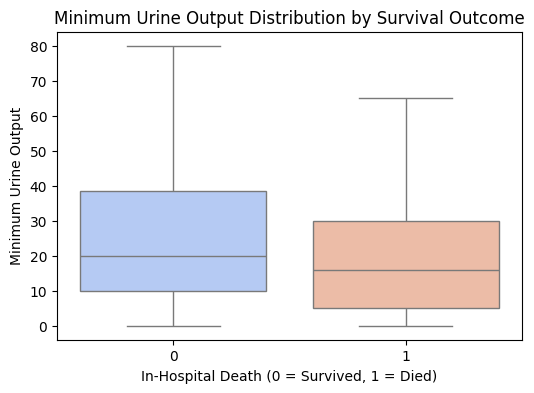

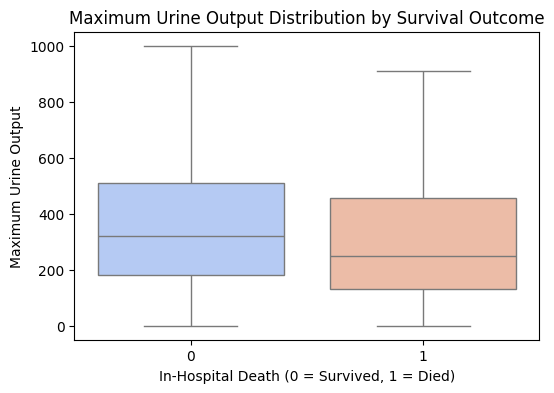

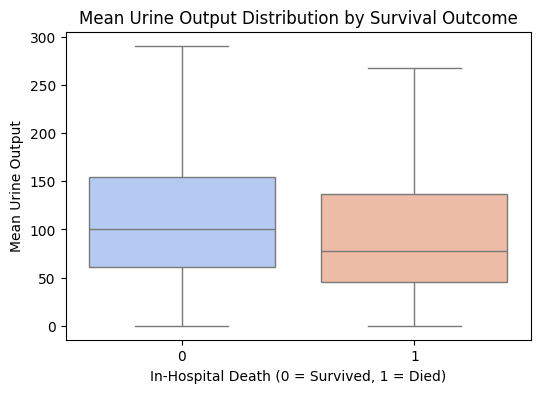

In [33]:
outcome_boxplot('Min_Urine.x', 'Minimum Urine Output', showfliers=False)
outcome_boxplot('Max_Urine.x', 'Maximum Urine Output', showfliers=False)
outcome_boxplot('Mean_Urine.x', 'Mean Urine Output', showfliers=False)


Patients who died have lower urine output on all three measures: mean 105.5 vs 124.7
and median 77.9 vs 100.8 on Mean_Urine.x. The difference is moderate and consistent in
direction across min, mean and max.


### Urine and Age


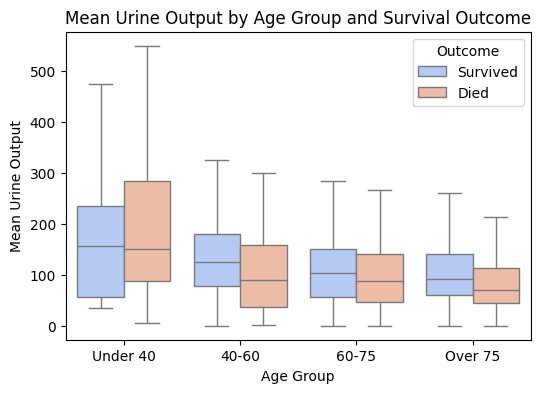

                          mean              median       
                  Mean_Urine.x        Mean_Urine.x       
In.hospital_death            0      1            0      1
AgeGroup                                                 
Under 40                 165.6  277.8        155.8  151.0
40-60                    146.9  106.8        125.0   89.4
60-75                    126.1  103.6        103.2   88.0
Over 75                  112.6   82.8         92.8   69.5


In [34]:
profile_boxplot('AgeGroup', 'Mean_Urine.x', 'Age Group', 'Mean Urine Output', showfliers=False)

print(df.pivot_table(index='AgeGroup', columns='In.hospital_death',
                     values=['Mean_Urine.x'], aggfunc=['mean', 'median'], observed=True).round(1))


Output declines with age in both outcome groups (survivors from about 166 down to 113).
In the 40-60, 60-75 and Over 75 groups, patients who died have clearly lower output.
The Under 40 group is the exception: its died mean (277.8) is higher than the survivor
mean (165.6), but that group has only 35 died patients and their values include one
extreme record of 3030 - the died median is 151. I would treat that reversal as a
small-sample artefact, not a real pattern.


### Urine and Gender


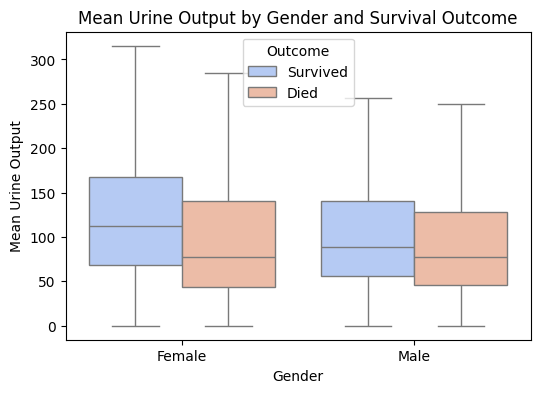

                    mean        median      
In.hospital_death      0      1      0     1
Sex                                         
Female             137.7  113.1  111.8  77.9
Male               109.5   96.5   89.1  77.1


In [35]:
profile_boxplot('Sex', 'Mean_Urine.x', 'Gender', 'Mean Urine Output', showfliers=False)

d = df[df['Sex'].notna()]
print(d.pivot_table(index='Sex', columns='In.hospital_death',
                    values='Mean_Urine.x', aggfunc=['mean', 'median']).round(1))


Females record higher urine output than males in both outcome groups. Within each
gender the same direction holds: patients who died have lower output than survivors
(medians 96.5 vs 109.5 for males, 113.1 vs 137.7 for females).


### Urine Summary

- Lower recorded urine output is associated with in-hospital death, on all three
  measures.
- The association holds in the three older age groups and in both genders; the Under 40
  exception is driven by one extreme record in a very small group.
- Main limitations: undocumented units, extreme right skew, and many zeros in the min
  column, so results describe relative differences only.


## Correlation Summary

As a compact overview, the plot below repeats the group's correlation approach
(Spearman, because most of these variables are skewed) for the fifteen columns covered
in this notebook.


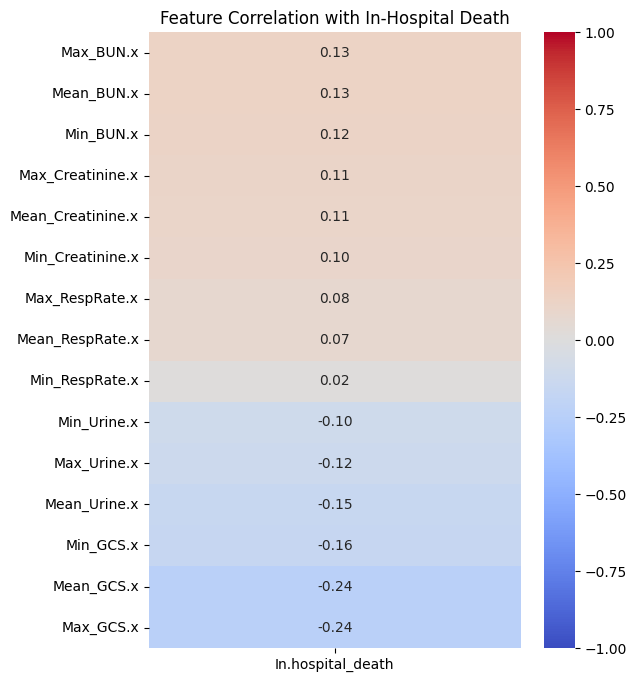

In [36]:
icu_features = gcs_cols + rr_cols + bun_cols + cre_cols + ur_cols + ['In.hospital_death']

death_corr = df[icu_features].corr(method='spearman')['In.hospital_death'].drop('In.hospital_death')
corr_df = pd.DataFrame(death_corr).sort_values(by='In.hospital_death', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Feature Correlation with In-Hospital Death')
plt.show()


The ranking matches the sections above: the GCS columns have the strongest (negative)
correlations with death (about -0.16 to -0.24), urine output is weakly negative
(about -0.10 to -0.15), BUN and creatinine are weakly positive (about 0.10 to 0.13),
and the RespRate columns sit at essentially zero (about 0.02 to 0.08). All of these are
modest values - none of the five variables is a strong standalone separator.


## Notes and Limitations

- This is exploratory analysis only: everything above describes associations observed
  in this dataset and cannot establish that any variable causes or prevents death.
- Only the `.x` columns were used, as agreed by the group; the duplicated `.y` columns
  were ignored.
- RespRate is the weakest part of the analysis: 74% of records share one identical
  imputed value set, so the flat result may reflect preprocessing rather than physiology.
- 2 records have an invalid Gender value; they are excluded from gender-specific plots
  only.
- The Under 40 age group contains only 55 patients, so its mortality estimate and its
  per-variable gaps (especially the urine reversal) are unstable.
- Urine output has undocumented units and extreme outliers; extreme points were hidden
  in a few plots for readability but no records were deleted.
- Mechanical ventilation was part of the original plan but was dropped after the group
  discussed it with the teacher, so it is not analysed here.
